<a href="https://colab.research.google.com/github/andrezconz/ans_taller_1/blob/main/S1_LC_Taller_PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

![Clase aprendizaje no supervisado](https://raw.githubusercontent.com/MECA4605-Aprendizaje-no-supervisado/taller_1/main/figs/taller-meca-aprendizaje%20no%20supervisado_banner%201169%20x%20200%20px%20-05.png)

# Caso-taller:  PCA para estudiar la dimensionalidad de la calidad de vida en las ciudades

En este caso-taller vamos a aplicar PCA en el estudio de calidad de vida en diferentes ciudades. Para ello, haremos uso de los datos que surgen del Almanaque Calificado de Lugares. En este Almanaque Boyer y Savageau calificaron 329 ciudades de acuerdo con los siguientes nueve criterios:

   - Clima y Terreno
   - Alojamiento
   - Cuidado de la salud y el medio ambiente
   - Crimen
   - Transporte
   - Educación
   - Artes
   - Recreación
   - Economía

Con tantas variables disponibles, la matriz de dispersión puede resultar muy grande para estudiarla e interpretarla adecuadamente. Habría demasiadas correlaciones bivariadas entre las variables a considerar. Para interpretar los datos de una forma más significativa es necesario reducir el número de variables a unas pocas dimensiones, y para ello en este ejercicio recurriremos al análisis de componentes principales.


## Instrucciones generales

1. Para desarrollar el *cuaderno* primero debe descargarlo junto al archivo de soporte.

2. Para responder cada inciso deberá utilizar el espacio debidamente especificado.

3. La actividad será calificada sólo si sube el *cuaderno* de jupyter notebook con extensión `.ipynb` en la actividad designada como "entrega calificada por el personal".

4. El archivo entregado debe poder ser ejecutado localmente por el tutor. Sea cuidadoso con la especificación de la ubicación de los archivos de soporte, guarde la carpeta de datos en la misma ruta de acceso del cuaderno, por ejemplo: `data/archivo_de_soporte.csv`.

## Desarrollo


### 1. Carga de datos

En el repositorio de taller 1 encontraran una carpeta `data` donde se encuentra el archivo `lugares.csv`, cargue estos datos en su *cuaderno*.


In [20]:
# =========================
# Carga de datos
# =========================

# Establecer el directorio de trabajo donde se encuentra el repositorio
%cd /content/taller_1

# Verificar los archivos disponibles en el directorio actual
import os
os.listdir()

# Verificar el contenido de la carpeta 'data'
os.listdir('data')

# Importar la librería pandas
import pandas as pd

# Cargar la base de datos 'lugares.csv'
df = pd.read_csv('data/lugares.csv')

# Visualizar las primeras filas para comprobar la carga
df.head()

/content/taller_1


,Ciudad,Clima y Terreno,Alojamiento,Cuidado de la salud y el medio ambiente,Crimen,Transporte,Educación,Artes,Recreación,Economía
0,"Abilene,TX",521,6200,237,923,4031,2757,996,1405,7633
1,"Akron,OH",575,8138,1656,886,4883,2438,5564,2632,4350
2,"Albany,GA",468,7339,618,970,2531,2560,237,859,5250
3,"Albany-Schenectady-Troy,NY",476,7908,1431,610,6883,3399,4655,1617,5864
4,"Albuquerque,NM",659,8393,1853,1483,6558,3026,4496,2612,5727


### 2.  Análisis descriptivo de las variables.

Para el análisis descriptivo haga uso de estadísticas descriptivas y matrices de correlación. Indique además cuantas gráficas de dispersión bivariadas debería examinar con este número de variables.

Explique porqué es importante conocer las estadísticas descriptivas y como contribuyen al ejercicio posterior de Análisis de Componentes Principales.

Tenga en cuenta que para las variables, a excepción de la alojamiento y crimen, cuanto mayor sea el puntaje, mejor. Por el contrario; para alojamiento y crimen, mientras más bajo sea el puntaje, mejor. También, mientras algunas comunidades podrían calificar mejor en las artes, otras podrían calificar mejor en otras áreas como tener una tasa de criminalidad más baja y buenas oportunidades educativas.

       Clima y Terreno   Alojamiento  Cuidado de la salud y el medio ambiente  \
count       329.000000    329.000000                               329.000000   
mean        538.732523   8346.559271                              1185.738602   
std         120.808259   2385.262622                              1003.002036   
min         105.000000   5159.000000                                43.000000   
25%         480.000000   6760.000000                               583.000000   
50%         542.000000   7877.000000                               833.000000   
75%         592.000000   9015.000000                              1445.000000   
max         910.000000  23640.000000                              7850.000000   

            Crimen   Transporte    Educación         Artes   Recreación  \
count   329.000000   329.000000   329.000000    329.000000   329.000000   
mean    961.054711  4210.082067  2814.887538   3150.884498  1845.957447   
std     357.154186  1451.179240   320.792953 

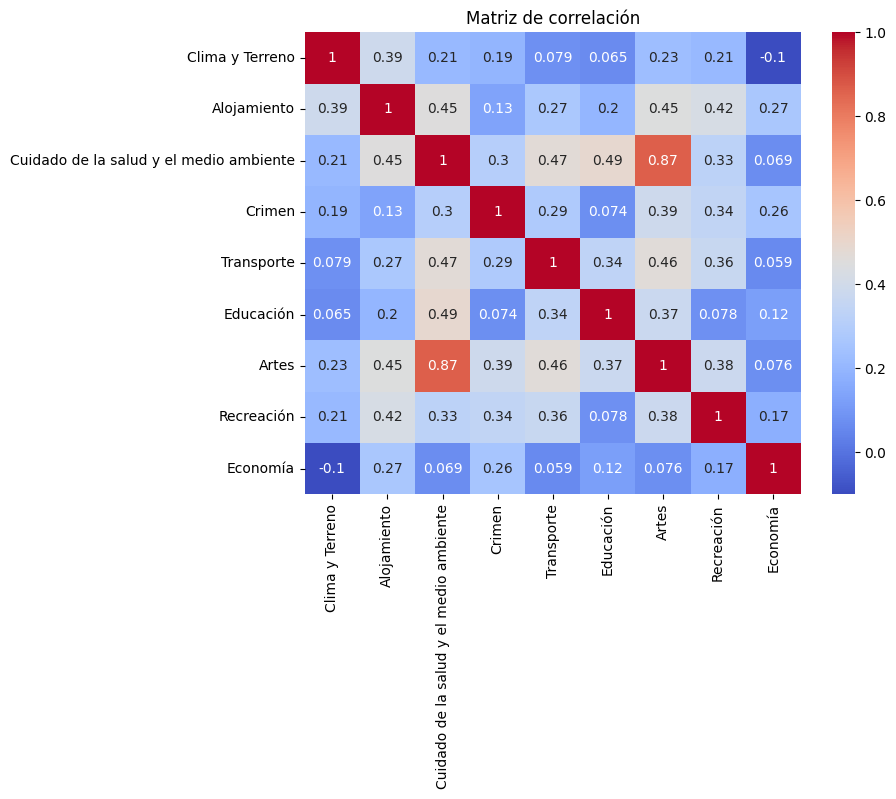

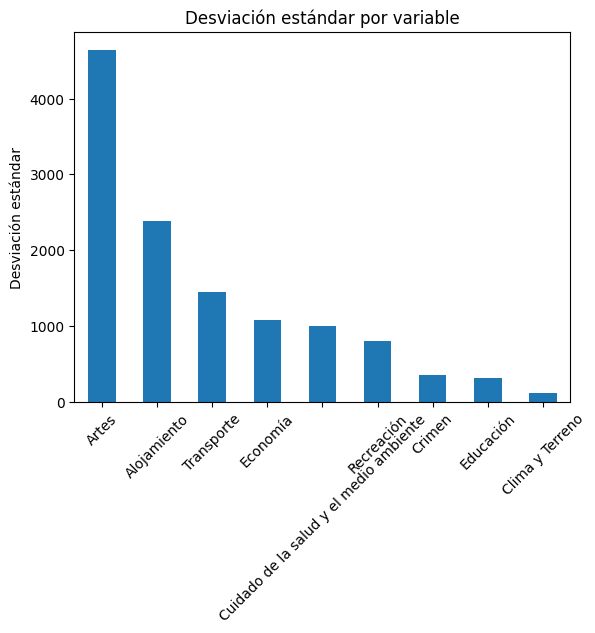

In [27]:
# =========================
# 2. Análisis descriptivo
# =========================

# Seleccionar solo variables numéricas
df_num = df.select_dtypes(include=['number'])

# -------------------------
# Estadísticas descriptivas
# -------------------------
desc = df_num.describe()
print(desc)

# -------------------------
# Desviación estándar (énfasis en dispersión)
# -------------------------
std_dev = df_num.std().sort_values(ascending=False)
print(std_dev)

# -------------------------
# Matriz de correlación
# -------------------------
import seaborn as sns
import matplotlib.pyplot as plt

corr = df_num.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Matriz de correlación')
plt.show()

# Gráfico de dispersión (variabilidad)
std_dev.plot(kind='bar')
plt.title('Desviación estándar por variable')
plt.ylabel('Desviación estándar')
plt.xticks(rotation=45)
plt.show()

Para el análisis descriptivo se calcularon estadísticas básicas como la media, desviación estándar, valores mínimos y máximos para cada variable. Esto permitió identificar diferencias importantes en la escala y dispersión de las variables.

En particular, se observa que variables como Artes y Alojamiento presentan una desviación estándar considerablemente mayor en comparación con el resto, lo que indica una alta variabilidad entre ciudades en estas dimensiones. Por el contrario, variables como Clima y Terreno y Educación presentan menor dispersión, lo que sugiere mayor homogeneidad entre las ciudades en estos aspectos.

Esta diferencia en la variabilidad justifica la necesidad de estandarizar las variables antes de aplicar PCA, ya que de lo contrario aquellas con mayor varianza (como Artes) dominarían el análisis.

Adicionalmente, se construyó la matriz de correlación, la cual permite identificar relaciones lineales entre variables. Se evidencian correlaciones moderadas y altas, destacándose la relación entre Cuidado de la salud y el medio ambiente y Artes (0.87), lo que sugiere que ambas variables podrían estar capturando una dimensión común del bienestar urbano.

Dado que el conjunto de datos contiene 9 variables, el número de gráficas de dispersión bivariadas posibles es: 36

Analizar manualmente estas 36 relaciones resulta poco eficiente, lo cual justifica el uso de técnicas de reducción de dimensionalidad como el PCA.
En este contexto, se opta por complementar el análisis con un gráfico de barras de la desviación estándar, ya que permite visualizar de forma clara qué variables presentan mayor dispersión y, por tanto, mayor influencia potencial en el análisis de componentes principales.

La diferencia en la dispersión observada entre las variables, especialmente en casos como "Artes" y "Alojamiento", sugiere que algunas dimensiones presentan una variabilidad considerablemente mayor que otras. Esto evidencia la necesidad de estandarizar las variables antes de aplicar el Análisis de Componentes Principales (PCA), con el fin de evitar que aquellas con mayor varianza dominen el análisis.

Finalmente, es importante considerar que, en la mayoría de variables, un mayor puntaje representa mejores condiciones de calidad de vida. Sin embargo, en las variables de Alojamiento y Crimen, un menor valor indica mejores condiciones. Esta diferencia es clave para la interpretación posterior de los componentes principales, ya que influye en el signo y significado de los mismos.


### 3.  Cálculo y selección de componentes principales.

Utilizando Álgebra Lineal, calcule los eigen valores y los eigen vectores, a partir de ellos obtenga los Componentes Principales. Tenga en cuenta de estandarizar las variables y explicar por qué es importante no omitir este paso.

Luego, examine los valores propios para determinar cuántos componentes principales se deben considerar. Explique el criterio que utilizó para la elección y justifique su respuesta.

In [ ]:
# Utilice este espacio para escribir el código.

(Utilice este espacio para describir el procedimiento, análisis, y conclusiones).

### 4.  Interpretación de los componentes principales.

Logró reducir la dimensión en el ejercicio anterior? Si lo hizo, pueden los pesos obtenidos identificar dimensiones menores de los datos? Provea una interpretación a estas dimensiones, para ello puede utilizar gráficas y/o tablas.

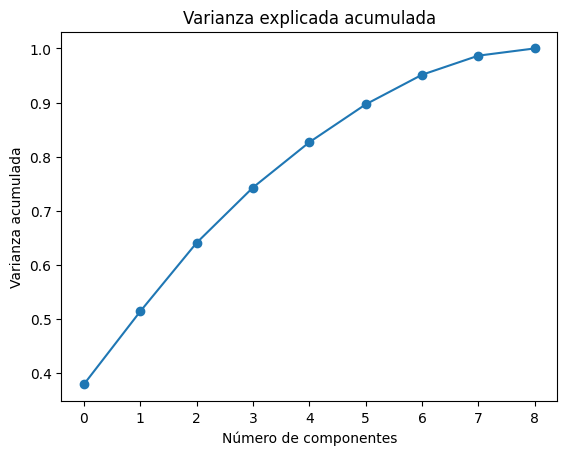

In [28]:
# =========================
# 3. PCA - Estandarización
# =========================

from sklearn.preprocessing import StandardScaler

# Estandarizar variables
scaler = StandardScaler()
X_std = scaler.fit_transform(df_num)

# Verificar media ~ 0 y varianza ~ 1
X_std.mean(axis=0), X_std.std(axis=0)

# =========================
# Matriz de covarianza
# =========================

import numpy as np

cov_matrix = np.cov(X_std.T)
cov_matrix

# =========================
# Eigenvalores y eigenvectores
# =========================

eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

# Ordenar de mayor a menor
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

eigenvalues

# =========================
# Varianza explicada
# =========================

var_exp = eigenvalues / np.sum(eigenvalues)
var_acum = np.cumsum(var_exp)

var_acum

# =========================
# Scree plot
# =========================

import matplotlib.pyplot as plt

plt.plot(var_acum, marker='o')
plt.xlabel('Número de componentes')
plt.ylabel('Varianza acumulada')
plt.title('Varianza explicada acumulada')
plt.show()

A partir de los eigenvalores obtenidos, se calculó la varianza explicada por cada componente principal y su acumulado. El gráfico de varianza explicada acumulada permite observar cuánta información se conserva al incluir un determinado número de componentes.

Los resultados muestran que el primer componente explica aproximadamente el 38% de la varianza total, mientras que los primeros cinco componentes explican cerca del 83%. Al incluir seis componentes principales, se alcanza aproximadamente el 90% de la varianza explicada.

En este caso, se decidió retener seis componentes principales, ya que permiten capturar la mayor parte de la variabilidad de los datos sin necesidad de mantener todas las variables originales. Este criterio se basa en el umbral comúnmente utilizado en la literatura, donde se busca conservar entre el 80% y 90% de la varianza total.

A partir de este resultado, se concluye que es posible reducir la dimensionalidad del problema de nueve variables a seis componentes principales, logrando una representación más compacta de la información sin una pérdida significativa de contenido.

Además, se observa que a partir del sexto componente la pendiente de la curva se reduce considerablemente, lo que indica rendimientos decrecientes en la varianza explicada al añadir más componentes.


### 5.   Detección de ciudades inusuales.

A partir de los Componentes Principales identifique las 5 ciudades calidad de vida inusualmente alta. En la distribución de calidad de vida  de la muestra que tan inusuales son? Cuáles son las dimensiones que hacen que estas ciudades tengan esta calidad de vida inusual?

,Componente,Varianza explicada,Varianza acumulada
0,PC1,0.379,0.379
1,PC2,0.135,0.514
2,PC3,0.127,0.640
3,PC4,0.102,0.743
4,PC5,0.084,0.826
5,PC6,0.070,0.897
6,PC7,0.055,0.951
7,PC8,0.035,0.987
8,PC9,0.013,1.000


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,Ciudad,Calidad_vida
212,12.445179,-2.064887,0.210083,-3.430722,-1.685713,5.591783,0.809112,1.186383,2.953919,"New-York,NY",12.445179
269,7.402662,1.228869,1.694329,0.406496,0.755162,-1.240956,-0.067004,-0.339275,-0.116252,"San-Francisco,CA",7.402662
178,7.257344,0.477878,2.054085,-0.522492,-1.657330,1.674207,-1.350943,0.145338,0.119359,"Los-Angeles,Long-Beach,CA",7.257344
64,6.474759,-3.091837,-0.392266,-0.390757,0.514411,1.789640,-0.036715,0.881872,0.144827,"Chicago,IL",6.474759
42,6.310655,-1.611192,-0.363214,0.276460,-0.173549,1.155180,-0.286317,0.973450,-0.120809,"Boston,MA",6.310655


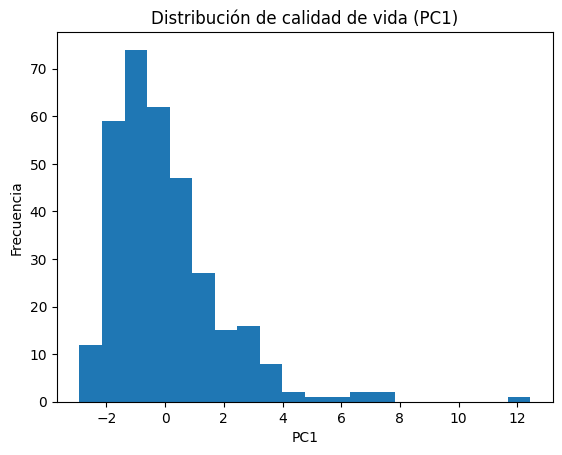

In [33]:
# =========================
# Tabla de varianza explicada
# =========================

import pandas as pd
from IPython.display import display

var_table = pd.DataFrame({
    'Componente': [f'PC{i+1}' for i in range(len(var_exp))],
    'Varianza explicada': var_exp,
    'Varianza acumulada': var_acum
})

# Mostrar tabla
display(var_table.round(3))


# =========================
# 5. Ciudades inusuales
# =========================

import numpy as np
import matplotlib.pyplot as plt

# Obtener componentes principales
PC = np.dot(X_std, eigenvectors)

# Crear DataFrame con componentes
pc_df = pd.DataFrame(PC, columns=[f'PC{i+1}' for i in range(len(df_num.columns))])

# Agregar nombres de ciudades
pc_df['Ciudad'] = df.iloc[:, 0]

# Índice de calidad de vida (PC1)
pc_df['Calidad_vida'] = pc_df['PC1']

# -------------------------
# Top 5 ciudades
# -------------------------
top5 = pc_df.sort_values('Calidad_vida', ascending=False).head(5)

display(top5)


# -------------------------
# Distribución de calidad de vida
# -------------------------
plt.figure()
plt.hist(pc_df['Calidad_vida'], bins=20)
plt.title('Distribución de calidad de vida (PC1)')
plt.xlabel('PC1')
plt.ylabel('Frecuencia')
plt.show()

A partir de los componentes principales obtenidos, se utilizó el primer componente principal (PC1) como un índice sintético de calidad de vida, dado que este explica la mayor proporción de la varianza total (37.9%). Este componente resume la información más relevante de las variables originales, permitiendo comparar las ciudades de manera agregada.

Con base en este índice, se identificaron las cinco ciudades con mayor calidad de vida: New York (NY), San Francisco (CA), Los Angeles–Long Beach (CA), Chicago (IL) y Boston (MA). Estas ciudades presentan los valores más altos en PC1, destacándose claramente del resto de la muestra.

En particular, New York presenta un valor significativamente superior (12.45), lo que la convierte en un caso extremadamente atípico en comparación con las demás ciudades. Las otras ciudades del top 5 también presentan valores altos, aunque con menor magnitud, lo que sugiere distintos niveles dentro del grupo de ciudades con alta calidad de vida.

Al analizar la distribución del índice de calidad de vida, se observa que estas ciudades se ubican en la cola derecha de la distribución, lo que indica que son observaciones inusuales o poco comunes dentro del conjunto de datos. La mayoría de las ciudades presentan valores cercanos al promedio, mientras que solo unas pocas alcanzan niveles significativamente superiores.

En términos de interpretación, estas ciudades destacan por combinaciones favorables en múltiples dimensiones. Dado que el primer componente principal captura una combinación de variables como educación, economía, salud, recreación y transporte, junto con niveles relativamente bajos de criminalidad y costos de alojamiento, se puede inferir que estas ciudades presentan condiciones generales superiores en varios aspectos de calidad de vida.

En conclusión, el uso del PCA permite identificar no solo patrones generales en los datos, sino también detectar ciudades con características excepcionalmente favorables, las cuales se diferencian claramente del resto de la muestra.